In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pt

In [ ]:
url = "https://raw.githubusercontent.com/Aditi960/Movie-Data-Analysis/main/IMDB-Movie-Data.csv"

# Load the movie dataset into a pandas DataFrame

In [ ]:
data = pd.read_csv(url)

#Check for Missing Values

Missing Values:
 Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64


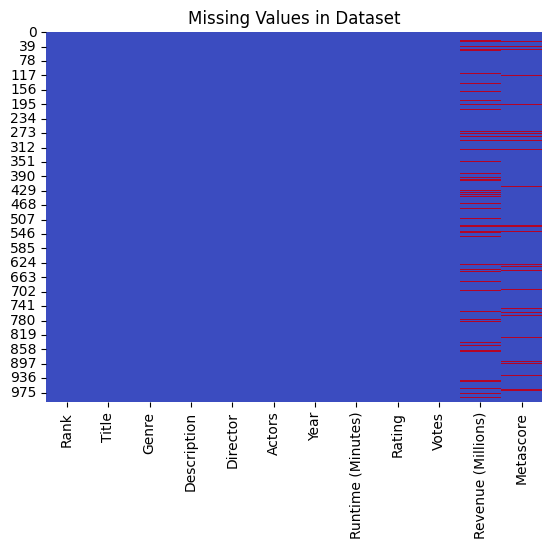

In [ ]:
print("Missing Values:\n", data.isnull().sum())

# Visualize missing values
sns.heatmap(data.isnull(), cmap="coolwarm", cbar=False)
pt.title("Missing Values in Dataset")
pt.show()

# Handle Missing Data

In [ ]:
# Fill missing numerical values with mean
data['Revenue (Millions)'].fillna(data['Revenue (Millions)'].mean(), inplace=True)
data['Metascore'].fillna(data['Metascore'].mean(), inplace=True)

# Drop remaining rows with missing values
data.dropna(inplace=True)

# Verify if missing values are handled
print("Missing Values after Cleaning:\n", data.isnull().sum())


 # Remove Duplicate Entries

In [ ]:
# Check for duplicate data
print("Are there any duplicate rows?", data.duplicated().any())

# Drop duplicate rows
data.drop_duplicates(inplace=True)


# 1.Total Number of Movies Released Each Year

In [ ]:
data['Year'].value_counts().sort_index()

,count
Year,
2006,44
2007,53
2008,52
2009,51
2010,60
2011,63
2012,64
2013,91
2014,98


# 2. Top 10 Directors with Most Movies

In [ ]:
data['Director'].value_counts().head(10)

,count
Director,
Ridley Scott,8
David Yates,6
M. Night Shyamalan,6
Paul W.S. Anderson,6
Michael Bay,6
Zack Snyder,5
Denis Villeneuve,5
Woody Allen,5
Peter Berg,5


# 3.Most Common Movie Genre

In [ ]:
data['Genre'].value_counts().idxmax()


'Action,Adventure,Sci-Fi'

# 4.Highest IMDb Rated Movie


In [ ]:
data.loc[data['Rating'].idxmax(), ['Title', 'Rating']]


,54
Title,The Dark Knight
Rating,9.0


# 5.Average IMDb Rating Per Year

In [ ]:
data.groupby('Year')['Rating'].mean()


# 6. Number of Movies Released Per Year

<ipython-input-10-e299ecf68d38>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Year', data=data, palette='coolwarm')


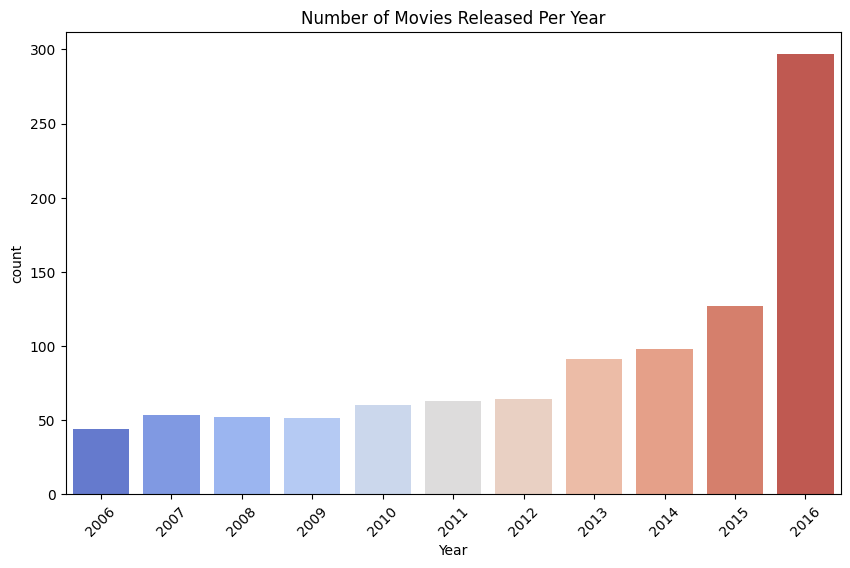

In [ ]:
pt.figure(figsize=(10, 6))
sns.countplot(x='Year', data=data, palette='coolwarm')
pt.xticks(rotation=45)
pt.title("Number of Movies Released Per Year")
pt.show()

# 7. Average IMDb Rating Per Year

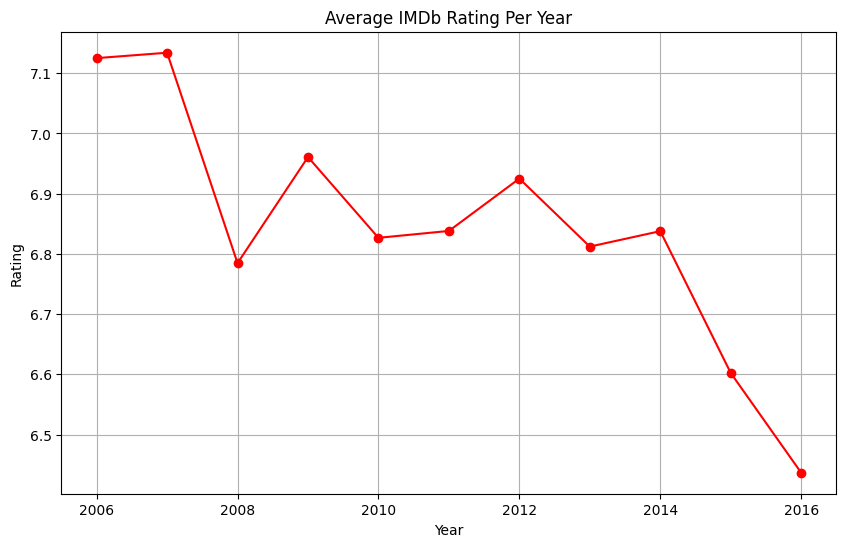

In [ ]:
avg_rating = data.groupby('Year')['Rating'].mean()
avg_rating.plot(kind='line', marker='o', figsize=(10, 6), color='red')
pt.title("Average IMDb Rating Per Year")
pt.xlabel("Year")
pt.ylabel("Rating")
pt.grid()
pt.show()

# 8. IMDb Rating vs. Number of Votes(Scatter Plot)

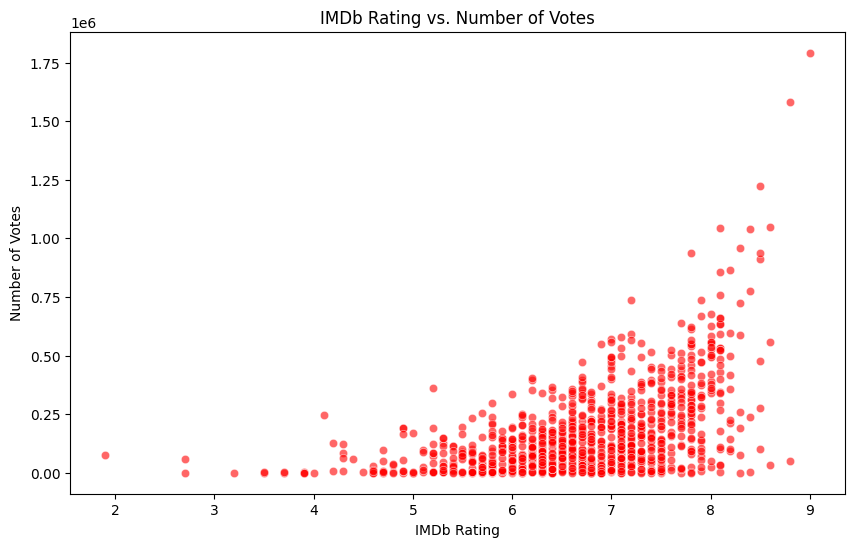

In [ ]:
pt.figure(figsize=(10,6))
sns.scatterplot(x=data['Rating'], y=data['Votes'], alpha=0.6, color='red')
pt.xlabel("IMDb Rating")
pt.ylabel("Number of Votes")
pt.title("IMDb Rating vs. Number of Votes")
pt.show()


# 9. Most Popular Movie Genres

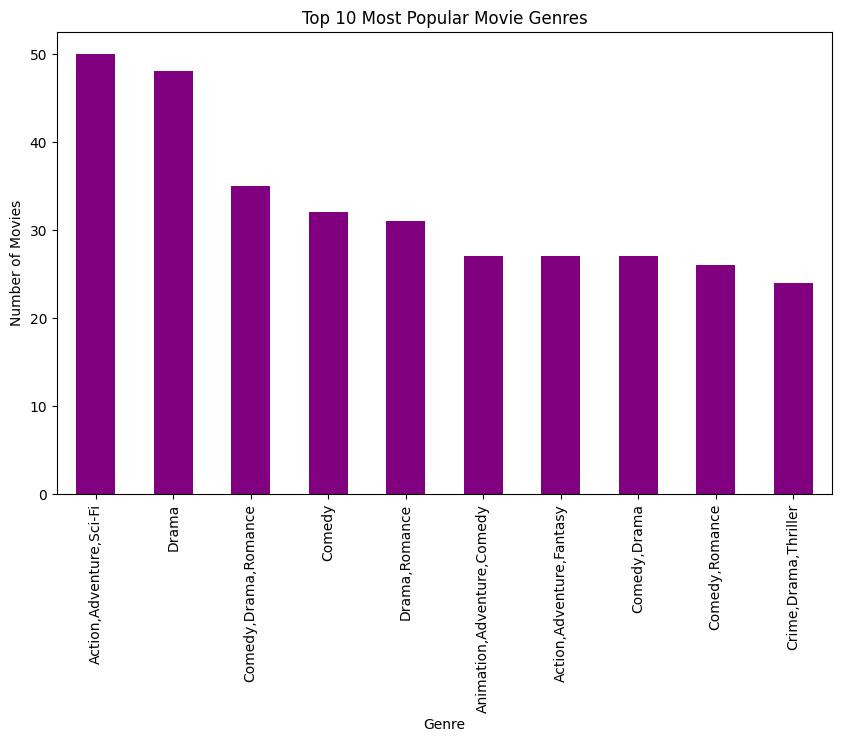

In [ ]:
genre_counts = data['Genre'].value_counts().head(10)
genre_counts.plot(kind='bar', figsize=(10, 6), color='purple')
pt.title("Top 10 Most Popular Movie Genres")
pt.xlabel("Genre")
pt.ylabel("Number of Movies")
pt.show()


# 10. Top 10 Highest Rated Movies

<ipython-input-14-2bc7803cecb1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_movies['Title'], x=top_movies['Rating'], palette='viridis')


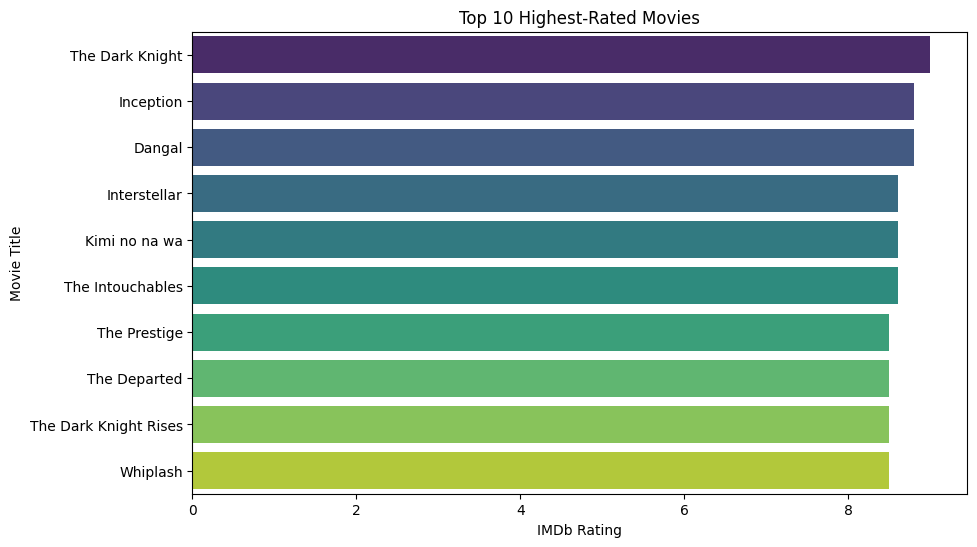

In [ ]:
top_movies = data.nlargest(10, 'Rating')[['Title', 'Rating']]
pt.figure(figsize=(10, 6))
sns.barplot(y=top_movies['Title'], x=top_movies['Rating'], palette='viridis')
pt.xlabel("IMDb Rating")
pt.ylabel("Movie Title")
pt.title("Top 10 Highest-Rated Movies")
pt.show()